In [1]:
from solve_gwf_1D import solve_gwf_1D
import os, torch, numpy as np, h5py, scipy.io as sio, matplotlib.pyplot as plt
import h5py
import numpy as np
from scipy.fft import idct

In [2]:
def sample_prior(alpha, tau, N):
    """
    Python version of the MATLAB function:

        function U = gaussrnd(alpha,tau,N)
            xi   = normrnd(0,1,1,N);
            K1   = 0:N-1;
            coef = (pi^2*(K1.^2) + tau^2).^(-alpha/2);
            L    = sqrt(N)*coef.*xi;
            L(1) = 0;
            U    = idct(L,'Type',2);
        end
    """

    # Random variables in KL expansion
    xi = np.random.normal(loc=0.0, scale=1.0, size=N)

    # (square root of) eigenvalues
    k = np.arange(N)
    coef = (np.pi**2 * (k**2) + tau**2)**(-alpha / 2.0)

    # KL coefficients
    L = np.sqrt(N) * coef * xi
    L[0] = 0.0

    # Inverse DCT-II (to match MATLAB's idct(...,'Type',2))
    U = idct(L, type=2, norm='ortho')

    return U


In [3]:
alpha = 2
tau = 3
N = 64
obs_idx = np.arange(3, 64, 8)   # start=3, stop=64, step=8
f=np.ones((N,))
sigma = 1e-3
burnin=200_000
n_samples=1_000_000+burnin


In [4]:
# loading the pairs of data and the observed pressure and the true u.
file_data="./../../../Data/Experiment3/darcy_data1D_64.mat"
with h5py.File(file_data, "r") as file:
    x = np.array(file["x"])
    y = np.array(file["y"])

In [5]:
x.shape

(64, 1000000)

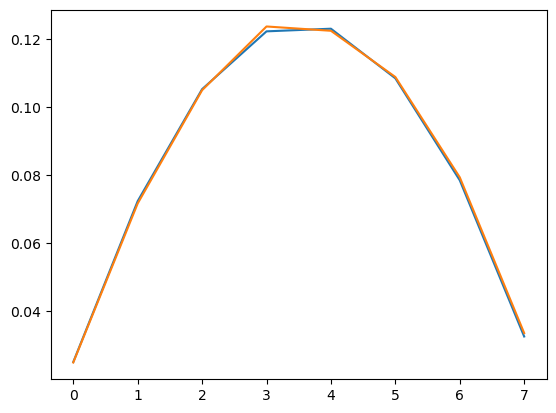

In [6]:
# For the most of the analysis I have used u_true = x[:,0], y_true = y[:,0]. To show the reproducability, I try different obs
index_data=-2
u_true = x[:,index_data]
y_true = y[:,index_data]
rng = np.random.default_rng(seed=1373)
noise = sigma * rng.normal(size=y_true.shape)
y_obs = y_true + noise
plt.plot(y_true)
plt.plot(y_obs)
np.savez("./../../../Data/Experiment3/darcy_single_sample"+str(index_data)+".npz", u_true=u_true, y_true=y_true, y_obs=y_obs)


In [7]:
# for i in range(10000):
#     plt.plot(x[:,i],alpha=0.2,color='black')

In [8]:
def loglik(u, y_obs, sigma, f, obs_idx):
    """
    Compute log-likelihood for Darcy inverse problem:
        y = H p(u) + noise

    Inputs:
        u       : log-permeability vector, shape (N,)
        y_obs   : observed pressures at 8 points, shape (8,)
        sigma   : noise std (iid)
        f       : forcing in Darcy solver
        obs_idx : list/array of indices for observed points

    Returns:
        scalar log-likelihood (up to additive constant)
    """

    # Solve Darcy forward problem
    p = solve_gwf_1D(np.exp(u), f)   # shape (N,)

    # Extract observations
    p_obs = p[obs_idx]         # shape (8,)

    # Gaussian likelihood
    misfit = p_obs - y_obs
    return -0.5 * np.sum((misfit / sigma)**2)


In [9]:

def pcn(loglik, alpha, tau, N, beta=0.1, n_samples=1000, burn=5000, thin=1, rng=None, u0=None):
    if rng is None:
        rng = np.random.default_rng()

    chain = np.zeros((n_samples, N))

    # initialize from the prior
    if u0 is None:
        u = sample_prior(alpha, tau, N)
    else:
        u = u0.copy()
    logl_u = loglik(u, y_obs, sigma, f, obs_idx)

    accepts = 0

    for k in range(n_samples):

        xi = sample_prior(alpha, tau, N)

        # proposal
        u_prop = np.sqrt(1-beta**2)*u + beta*xi

        logl_prop = loglik(u_prop, y_obs, sigma, f, obs_idx)
        log_alpha = logl_prop - logl_u

        if np.log(rng.uniform()) < log_alpha:
            u = u_prop
            logl_u = logl_prop
            accepts += 1

        chain[k] = u

    print("Acceptance rate:", accepts / n_samples)
    return chain[burn::thin]


In [10]:
chain=pcn(loglik, alpha, tau, N, beta=0.3, n_samples=n_samples, burn=burnin, thin=1, u0=u_true)

Acceptance rate: 0.40650833333333336


In [11]:
np.savez("./../../../Data/Experiment3/pcn_chain_indexdata"+str(index_data)+".npz", chain=chain)


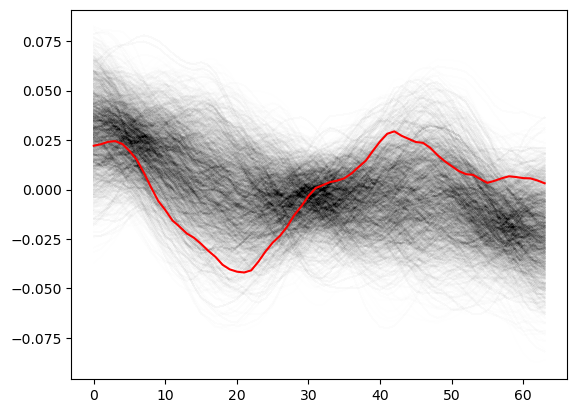

In [12]:
for i in range(5000):
    plt.plot(chain[-i,:],color='black',alpha=0.005)
plt.plot(u_true,color='red')


In [13]:
# This code test the prior code
# import numpy as np
# from scipy.fft import idct
# import matplotlib.pyplot as plt

# # ---------------------------------------------------------
# # Your sampler
# # ---------------------------------------------------------
# def gaussrnd(alpha, tau, N, rng=None):
#     if rng is None:
#         rng = np.random.default_rng()
#     xi = rng.normal(size=N)
#     k = np.arange(N)
#     coef = (np.pi**2 * k**2 + tau**2)**(-alpha/2)
#     L = np.sqrt(N) * coef * xi
#     L[0] = 0.0
#     return idct(L, type=2, norm='ortho')


# # ---------------------------------------------------------
# # Full verification function (Python version of your MATLAB code)
# # ---------------------------------------------------------
# def test_gaussrnd(alpha=2, tau=5, N=64, Nsamp=50000, rng=None):

#     if rng is None:
#         rng = np.random.default_rng()

#     # -----------------------------------------------------
#     # 1. Grid: x_i = (i - 0.5)/N
#     # -----------------------------------------------------
#     i = np.arange(1, N+1)
#     x = (i - 0.5) / N   # shape: (N,)

#     # -----------------------------------------------------
#     # 2. Generate Monte Carlo samples
#     # -----------------------------------------------------
#     U_samples = np.zeros((N, Nsamp))
#     for n in range(Nsamp):
#         U_samples[:, n] = gaussrnd(alpha, tau, N, rng)

#     # empirical covariance
#     C_emp = np.cov(U_samples)

#     # -----------------------------------------------------
#     # 3. Theoretical covariance via KL expansion
#     # -----------------------------------------------------
#     k = np.arange(N)
#     lam = (np.pi**2 * k**2 + tau**2)**(-alpha)
#     lam[0] = 0.0   # remove constant mode

#     # Build DCT-II eigenfunctions
#     Phi = np.zeros((N, N))
#     Phi[:, 0] = 1.0
#     for kk in range(1, N):
#         Phi[:, kk] = np.sqrt(2) * np.cos((kk) * np.pi * x)

#     # KL covariance: Phi diag(lambda) Phi^T
#     C_th = Phi @ np.diag(lam) @ Phi.T

#     # -----------------------------------------------------
#     # 4. Comparison metrics
#     # -----------------------------------------------------
#     frob_err = np.linalg.norm(C_emp - C_th, 'fro') / np.linalg.norm(C_th, 'fro')
#     trace_ratio = np.trace(C_emp) / np.trace(C_th)

#     idx = 10
#     emp_var = C_emp[idx, idx]
#     th_var = C_th[idx, idx]
#     mean_val = np.mean(U_samples[idx, :])

#     print(f"Relative Frobenius error (Emp vs C_th) = {frob_err:.3e}")
#     print(f"Trace ratio trace(C_emp)/trace(C_th) = {trace_ratio:.6f} (should be ~1)")
#     print(f"Var at i={idx}: Emp = {emp_var:.4e}, Th = {th_var:.4e}")
#     print(f"Mean of u({idx}): {mean_val:.3e} (should be ~0)")

#     # -----------------------------------------------------
#     # 5. Plot
#     # -----------------------------------------------------
#     fig, axs = plt.subplots(1, 3, figsize=(14, 4))

#     im0 = axs[0].imshow(C_emp)
#     axs[0].set_title("Empirical Covariance")
#     plt.colorbar(im0, ax=axs[0])

#     im1 = axs[1].imshow(C_th)
#     axs[1].set_title("Theoretical C_th (KL)")
#     plt.colorbar(im1, ax=axs[1])

#     im2 = axs[2].imshow(C_emp - C_th)
#     axs[2].set_title("Difference Emp - C_th")
#     plt.colorbar(im2, ax=axs[2])

#     plt.tight_layout()
#     plt.show()

#     return C_emp, C_th, frob_err
# C_emp, C_th, err = test_gaussrnd()
